<a href="https://colab.research.google.com/github/EsserMishelle/credit-card-fraud-detection-ml/blob/main/Credit_Card_Fraud_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This project uses a synthetic financial transactions dataset to build a fraud detection model. Due to the large size of the original dataset (over 200,000 transactions), a smaller subset of 1,000 transactions is used for the modeling analysis. A logistic regression model is trained to predict whether a transaction is fraudulent based on transaction behavior and balance-related features.


---
# Loading


In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the data
# Reset index to ensure 'step' is treated as a feature column, not an index
transactions = pd.read_csv('transactions_modified.csv', index_col=0)
transactions= transactions.reset_index()

# Exploratory Data Analysis (EDA)

In [ ]:
display(transactions.head(20))
print(transactions.info())

,index,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isPayment,isMovement,accountDiff
0,0,206,CASH_OUT,62927.08,C473782114,0.00,0.00,C2096898696,649420.67,712347.75,0,0,1,649420.67
1,1,380,PAYMENT,32851.57,C1915112886,0.00,0.00,M916879292,0.00,0.00,0,1,0,0.00
2,2,570,CASH_OUT,1131750.38,C1396198422,1131750.38,0.00,C1612235515,313070.53,1444820.92,1,0,1,818679.85
3,3,184,CASH_OUT,60519.74,C982551468,60519.74,0.00,C1378644910,54295.32,182654.50,1,0,1,6224.42
4,4,162,CASH_IN,46716.01,C1759889425,7668050.60,7714766.61,C2059152908,2125468.75,2078752.75,0,0,0,5542581.85
5,5,350,PAYMENT,16013.85,C2093859850,72766.00,56752.15,M1803659246,0.00,0.00,0,1,0,72766.00
6,6,306,CASH_OUT,277310.34,C1480259234,0.00,0.00,C410033330,13379400.65,13656710.99,0,0,1,13379400.65
7,7,332,CASH_OUT,184157.68,C399464792,188588.19,4430.51,C295235726,358753.74,542911.42,0,0,1,170165.55
8,8,330,CASH_IN,136804.02,C304503510,20781.00,157585.02,C1682763714,707549.54,570745.52,0,0,0,686768.54
9,9,259,CASH_IN,60609.99,C2089244493,2907876.74,2968486.73,C277506714,823473.00,762863.01,0,0,0,2084403.74


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   index           1000 non-null   int64  
 1   step            1000 non-null   int64  
 2   type            1000 non-null   object 
 3   amount          1000 non-null   float64
 4   nameOrig        1000 non-null   object 
 5   oldbalanceOrg   1000 non-null   float64
 6   newbalanceOrig  1000 non-null   float64
 7   nameDest        1000 non-null   object 
 8   oldbalanceDest  1000 non-null   float64
 9   newbalanceDest  1000 non-null   float64
 10  isFraud         1000 non-null   int64  
 11  isPayment       1000 non-null   int64  
 12  isMovement      1000 non-null   int64  
 13  accountDiff     1000 non-null   float64
dtypes: float64(6), int64(5), object(3)
memory usage: 109.5+ KB
None


In [ ]:
# Summary statistics on amount column
transactions.describe()

,index,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isPayment,isMovement,accountDiff
count,1000.000000,1000.000000,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,499.500000,280.664000,5.373080e+05,1.049284e+06,6.376146e+05,1.028848e+06,1.302326e+06,0.282000,0.220000,0.605000,1.744828e+06
std,288.819436,167.174593,1.423692e+06,3.226500e+06,2.717351e+06,2.678541e+06,3.038042e+06,0.450198,0.414454,0.489095,3.792962e+06
min,0.000000,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00
25%,249.750000,164.000000,2.933705e+04,1.287500e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,4.273675e+04
50%,499.500000,261.000000,1.265305e+05,4.371400e+04,0.000000e+00,3.881927e+04,1.956572e+05,0.000000,0.000000,1.000000,3.383816e+05
75%,749.250000,373.250000,3.010378e+05,4.080914e+05,3.795663e+04,7.747167e+05,1.185959e+06,1.000000,0.000000,1.000000,1.759913e+06
max,999.000000,741.000000,1.000000e+07,5.039905e+07,4.039905e+07,3.085651e+07,3.183962e+07,1.000000,1.000000,1.000000,5.039905e+07


## We want to find out how many fraudulent rows are in the sample dataset

In [ ]:
fraud_count = transactions['isFraud'].value_counts()

display(fraud_count)
print(f'There are {fraud_count[1]} fraudulent transactions out of {len(transactions)} transactions.')

,count
isFraud,
0,718
1,282


There are 282 fraudulent transactions out of 1000 transactions.


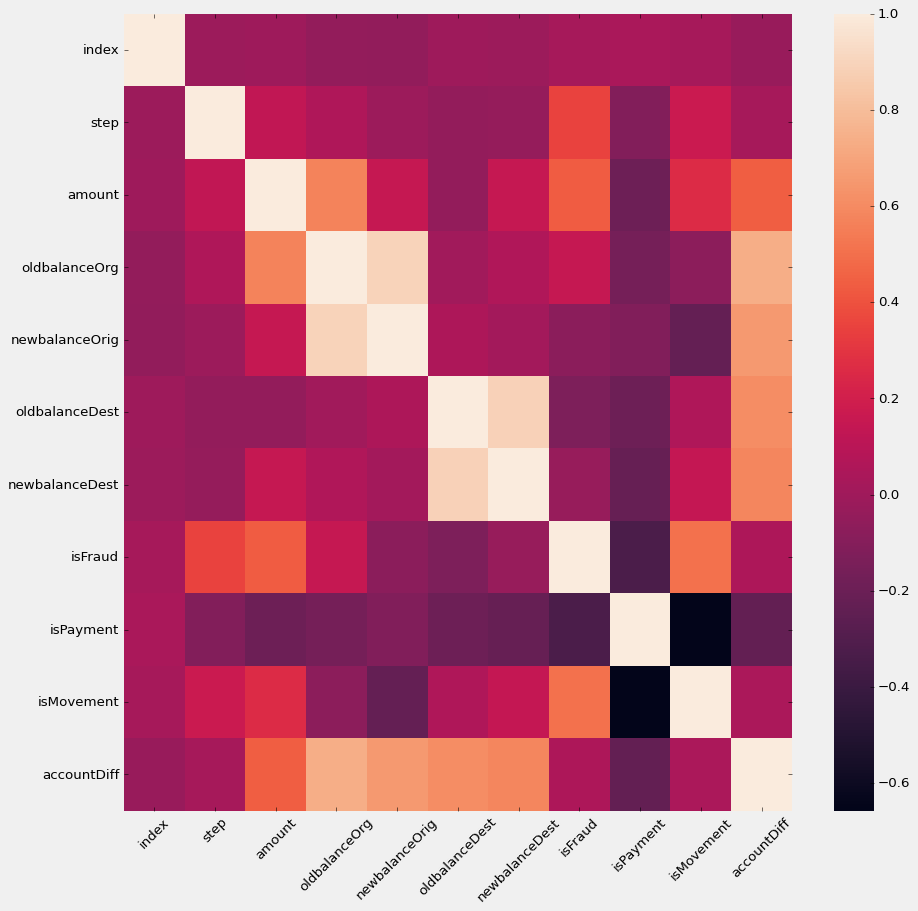

In [ ]:
# Let's see the correlation among the features
plt.figure(figsize=(12, 12))
plt.style.use('classic') # something thirty eight
sns.heatmap(transactions.corr(numeric_only=True))
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Correlation sorted in decending order
transactions.corr(numeric_only= True).round(3)

,index,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isPayment,isMovement,accountDiff
index,1.000,-0.014,-0.007,-0.046,-0.053,-0.004,-0.013,0.028,0.040,0.028,-0.025
step,-0.014,1.000,0.130,0.056,-0.011,-0.046,-0.042,0.352,-0.107,0.170,0.026
amount,-0.007,0.130,1.000,0.568,0.149,-0.045,0.146,0.435,-0.196,0.258,0.438
oldbalanceOrg,-0.046,0.056,0.568,1.000,0.895,0.009,0.062,0.149,-0.164,-0.069,0.736
newbalanceOrig,-0.053,-0.011,0.149,0.895,1.000,0.053,0.014,-0.080,-0.116,-0.225,0.657
oldbalanceDest,-0.004,-0.046,-0.045,0.009,0.053,1.000,0.884,-0.128,-0.198,0.060,0.610
newbalanceDest,-0.013,-0.042,0.146,0.062,0.014,0.884,1.000,-0.033,-0.222,0.142,0.580
isFraud,0.028,0.352,0.435,0.149,-0.080,-0.128,-0.033,1.000,-0.333,0.506,0.052
isPayment,0.040,-0.107,-0.196,-0.164,-0.116,-0.198,-0.222,-0.333,1.000,-0.657,-0.233
isMovement,0.028,0.170,0.258,-0.069,-0.225,0.060,0.142,0.506,-0.657,1.000,0.046


In [ ]:
transactions.corr(numeric_only= True)['isFraud'].sort_values(ascending = False).round(3)

,isFraud
isFraud,1.000
isMovement,0.506
amount,0.435
step,0.352
oldbalanceOrg,0.149
accountDiff,0.052
index,0.028
newbalanceDest,-0.033
newbalanceOrig,-0.080
oldbalanceDest,-0.128


## Discovery (Exploratory Data Analysis)

### Observations
- Fraud is most positively correlated with `isMovement` (0.51) and `amount` (0.44).
- Fraud is negatively correlated with `isPayment` (-0.33).
- The `step` feature shows moderate correlation but represents time ordering rather than transaction behavior.

### Important Considerations
The `step` feature represents the number of hours since the beginning of the dataset rather than a real-world business attribute. Because future steps would not be known at prediction time, including this feature could introduce data leakage. For this reason, `step` is excluded from feature engineering.

# Feature Engineering & Preprocessing
Based on patterns observed during exploratory analysis, several features were engineered to capture transaction intent and balance behavior.

In [ ]:
transactions['isMovement'] = transactions['type'].isin(['CASH_OUT', 'TRANSFER']).astype(int)

In [ ]:
transactions['isPayment'] = transactions['type'].isin(['PAYMENT', 'DEBIT']).astype(int)

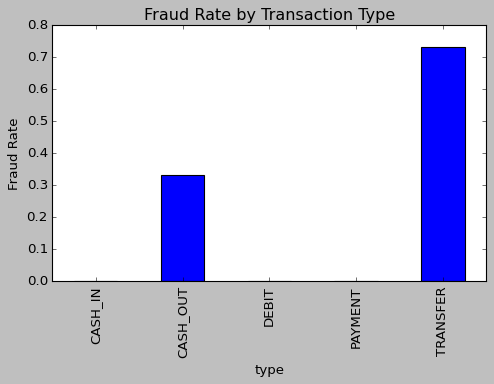

In [ ]:
fraud_by_type = transactions.groupby('type')['isFraud'].mean()

fraud_by_type.plot(kind='bar', figsize=(7,4))
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Transaction Type')
plt.show()

### Transaction Type Analysis:
Fraud rates vary dramatically by transaction type:
- **TRANSFER** transactions have the highest fraud rate (~73%)
- **CASH_OUT** transactions show elevated fraud (~37%)
- **PAYMENT**, **DEBIT**, and **CASH_IN** transactions exhibit near-zero fraud rates

These patterns suggest that fraud risk is associated with transaction behavior rather than individual transaction labels. Instead of one-hot encoding transaction types, I group them into behavioral indicators. We use `isMovement` to flag higher-risk money movement (`CASH_OUT`, `TRANSFER`) and `isPayment` to flag lower-risk payment activity (`PAYMENT`, `DEBIT`).


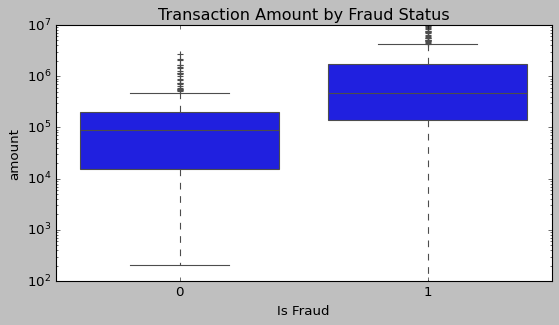

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(data=transactions, x='isFraud', y='amount')
plt.yscale('log')
plt.xlabel('Is Fraud')
plt.title('Transaction Amount by Fraud Status')
plt.show()


### Transaction Amount by Fraud Status Analysis:
* A log scale is used due to the heavy right skew in transaction amounts.
* The log scale highlights that fraud is more common among high-value transactions.
* While large amounts increase fraud occurances, they do not imply fraud by themselves.
* Therefore, *amount* will be included as a supporting feature along with other features.

In [ ]:
# Transaction `amount` alone does not capture realistic balances update.
# We will use `accountDiff` to measure the absolute change in the destination balance
# in order to identify abnormal or inconsistent balance behavior.

transactions['accountDiff'] = (
    transactions['oldbalanceDest'] - transactions['newbalanceDest']
).abs()

In [ ]:
# Let's include 2 more features that serve as flags for suspecicious behaviors:
# To avoid false positive due to floating-point precision, we will use sps

eps = 1e-6

transactions['origBalanceMismatch'] = (
    (transactions['oldbalanceOrg'] - transactions['amount'] != transactions['newbalanceOrig']).abs() / eps
).astype(int)
transactions['destBalanceMismatch'] = (
    (transactions['oldbalanceDest'] + transactions['amount'] != transactions['newbalanceDest']).abs() / eps
).astype(int)


In [ ]:
# Create features and label variables
features = [
    'amount',
    'isPayment',
    'isMovement',
    'accountDiff',
    'origBalanceMismatch',
    'destBalanceMismatch'
]

label= 'isFraud'

# Split dataset
X = transactions[features]
y = transactions[label]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [ ]:
# Normalize/scaler scale the features variables

# Binary features were scaled alongside numeric features for pipeline simplicity
# This does not affect logistic regression performance

ss = StandardScaler()
X_train_ss = ss.fit_transform(X_train)
X_test_ss = ss.transform(X_test)

# Model Training

In [ ]:
# Train the logistic regression on scaled training data
lr = LogisticRegression()
lr.fit(X_train_ss, y_train)


LogisticRegression()

In [ ]:
# Here will fit LogisticRegression .fit() and find out the training & test accuracies/scores
# This will be our baseline performance

# Score the model on the training data
lr.score(X_train_ss, y_train)

# Score the model on the test data
lr.score(X_test_ss, y_test)

print(f'Train accuracy: {lr.score(X_train_ss, y_train)}')
print(f'Test accuracy: {lr.score(X_test_ss, y_test)}')

# Print the model coefficients
print(f'The logistic model\'s coefficients: {lr.coef_}')


Train accuracy: 0.9871428571428571
Test accuracy: 0.9733333333333334
The logistic model's coefficients: [[ 1.43164537 -1.59183199  1.46504501  0.0285473  -3.53814011  0.26032241]]


Both the train and test accuracy score above 97% with a slight overfitting.

# Model Evaluation & Interpretation
### Confusion Matrix

[[201   8]
 [  0  91]]


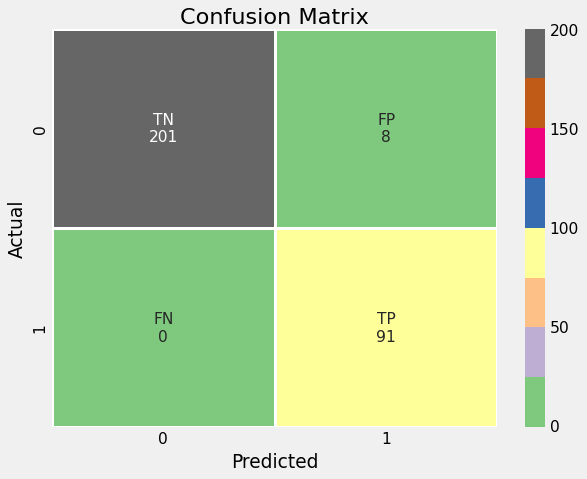

In [ ]:
from sklearn.metrics import confusion_matrix
y_pred = lr.predict(X_test_ss)
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.style.use('fivethirtyeight')
labels = np.array([
    ['TN\n201', 'FP\n8'],
    ['FN\n0', 'TP\n91']
])
sns.heatmap(
    cm,
    annot=labels,
    fmt='',
    cmap= 'Accent',
    linewidths=1,
    linecolor='white'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Confusion Matrix Analysis:
### There are:  
  - True Negatives (TN) = 201
  - False Positives (FP) = 8
  - False Negatives (FN) = 0
  - True Positives (TP) = 91

* The model achieves high recall (no missed fraud cases) with a small number of false positives (8). While performance is strong on this dataset, results may be optimistic due to the synthetic nature of the data and engineered rule-based features (balance mismatches).




In [ ]:
from sklearn.metrics import classification_report

y_pred = lr.predict(X_test_ss)

print('\nClassification Report: ')
print(classification_report(y_test, y_pred))


Classification Report: 
              precision    recall  f1-score   support

           0       0.83      0.99      0.90       209
           1       0.94      0.53      0.68        91

    accuracy                           0.85       300
   macro avg       0.88      0.76      0.79       300
weighted avg       0.86      0.85      0.83       300



## Classification Report Analysis


* The test accuracy scores an excellent 91% with little overfitting.
* When the model predicts, it has a perfect 100% precision rate and 92% rate of predicting non-fraud and faudulent transactions.
* The recall rates of 96% of non-fraud and 100% of faudulent activies concur with confusion matrix analysis.
* It has a 97% f1 score.
* Because fraud is supposedly relatively rare, these metrics alone can be misleading; therefore, recall and ROC-AUC are more informative metrics for model evaluation.


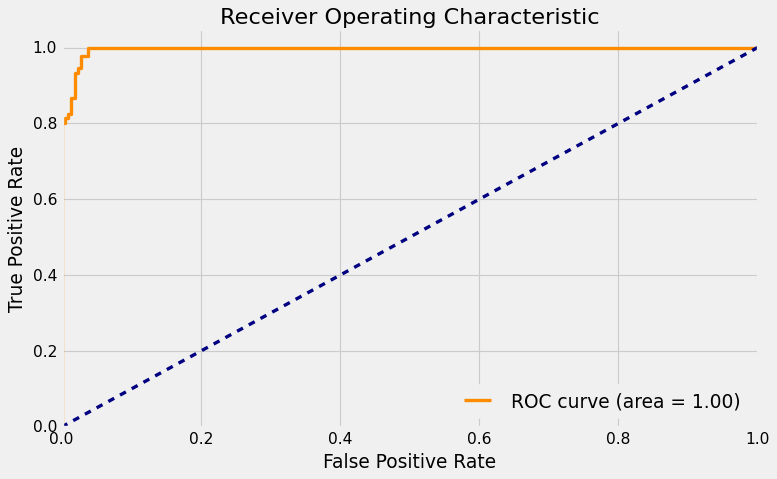

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, auc

y_pred = lr.predict(X_test_ss)
y_probs =lr.predict_proba(X_test_ss)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.style.use('fivethirtyeight')
plt.plot(fpr, tpr, color='darkorange', lw=3, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=3, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# ROC AUC Curve Analysis:
The ROC curve shows how well the model identifies fraudulent transactions while controlling false larms. An AUC of 1.00 indicates the model's near-perfect fraud identifying performance. However, this performance is likely optimistic given the synthetic nature of the data and the inclusion of strong rule-based features (mismatch balances)


---

# Coefficient Bar Chart -
to interpret logistic regression




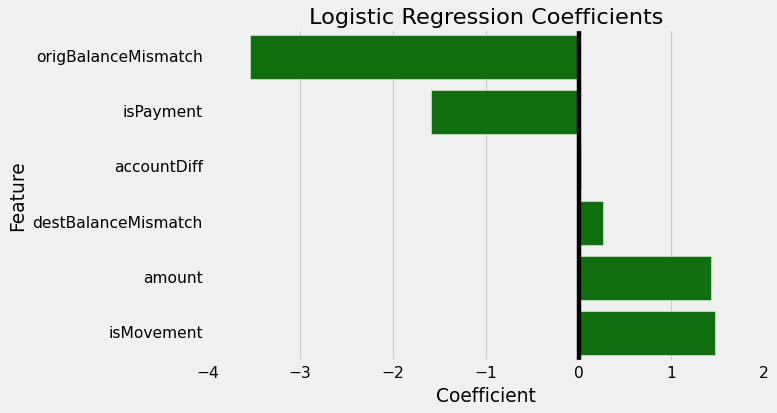

In [ ]:
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr.coef_[0]
}).sort_values(by='Coefficient')

plt.figure(figsize=(8,5))
plt.style.use('fivethirtyeight')
sns.barplot(data=coef_df, x='Coefficient', y='Feature', color='green')
plt.title('Logistic Regression Coefficients')
plt.axvline(0, color='black')
plt.show()


## Coefficient Analysis:
* According to the chart, `amount` and `isMovement` have the strongest coefficients, indicating that large amount and money-movements have strong association with fraud.  
* However, `isPayment` and `accountDiff` have negative coefficients, indicating they are associated with a lower probability of fraud.
* The mismatch balance features might have added signal for the model to detect abnormal behavior.

---

# Reduced feature set
The coefficient analysis highlights the `origBalanceMismatch` feature, which the model relies on most strongly. While balance mismatch indicators (`origBalanceMismatch`, `destBalanceMismatch`) contribute significantly to performance, they features may not always be available at transaction time and can introduce optimistic results in offline evaluation.

To assess model robustness and real-world applicability, I will retrain and evaluate the model using a reduced feature set that excludes balance mismatch flags. All other steps remain unchanged, allowing for a direct comparison of model behavior and performance.

In [ ]:
# Reduced feature set and label variables
features = [
    'amount',
    'isPayment',
    'isMovement',
    'accountDiff',
    ]

label= 'isFraud'

# Split dataset
X = transactions[features]
y = transactions[label]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [ ]:
# Normalize/scaler scale the features variables

# Binary features were scaled alongside numeric features for pipeline simplicity
# This does not affect logistic regression performance

ss = StandardScaler()
X_train_ss = ss.fit_transform(X_train)
X_test_ss = ss.transform(X_test)

In [ ]:
# Train the logistic regression on scaled training data
lr = LogisticRegression()
lr.fit(X_train_ss, y_train)


LogisticRegression()

In [ ]:
# Here will fit LogisticRegression .fit() and find out the training & test accuracies/scores
# This will be our baseline performance

# Score the model on the training data
lr.score(X_train_ss, y_train)

# Score the model on the test data
lr.score(X_test_ss, y_test)

print(f'Train accuracy: {lr.score(X_train_ss, y_train)}')
print(f'Test accuracy: {lr.score(X_test_ss, y_test)}')

# Print the model coefficients
print(f'The logistic model\'s coefficients: {lr.coef_}')


Train accuracy: 0.8371428571428572
Test accuracy: 0.8466666666666667
The logistic model's coefficients: [[ 3.55048017 -0.53717308  2.1673868  -2.16821361]]


[[206   3]
 [ 43  48]]


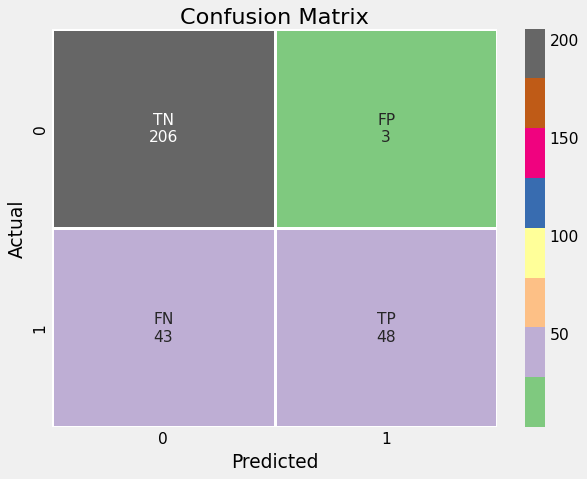

In [ ]:
from sklearn.metrics import confusion_matrix
y_pred = lr.predict(X_test_ss)
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.style.use('fivethirtyeight')
labels = np.array([
    ['TN\n206', 'FP\n3'],
    ['FN\n43', 'TP\n48']
])
sns.heatmap(
    cm,
    annot=labels,
    fmt='',
    cmap= 'Accent',
    linewidths=1,
    linecolor='white'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

y_pred = lr.predict(X_test_ss)

print('\nClassification Report: ')
print(classification_report(y_test, y_pred))


Classification Report: 
              precision    recall  f1-score   support

           0       0.83      0.99      0.90       209
           1       0.94      0.53      0.68        91

    accuracy                           0.85       300
   macro avg       0.88      0.76      0.79       300
weighted avg       0.86      0.85      0.83       300



* The logic regression achieves a strong overal accuracy of 84%
* When the model predicts non-fraud and fraud activities, it is correct 83% and 94% of the time, respectfully
* However, the main weakness is the recall for faud. It only catches 53% of actual fraudulent transactions and 99% of non-faud transactions.
* It has an excellent and moderate performance of fraud of non fraud f1 scores.
* The metrics indicate the the model tends to miss a portion of faudulent transactions. The trade-off reflects conservative prediction behavior and highlights class imbalance effects.

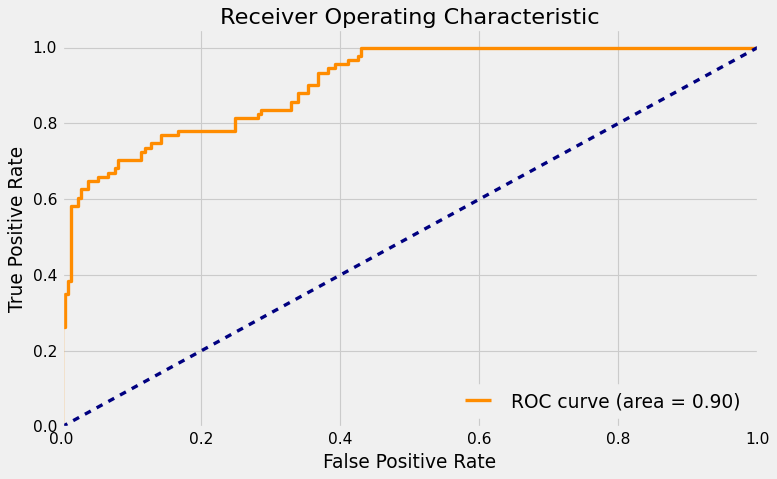

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, auc

y_pred = lr.predict(X_test_ss)
y_probs =lr.predict_proba(X_test_ss)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.style.use('fivethirtyeight')
plt.plot(fpr, tpr, color='darkorange', lw=3, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=3, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

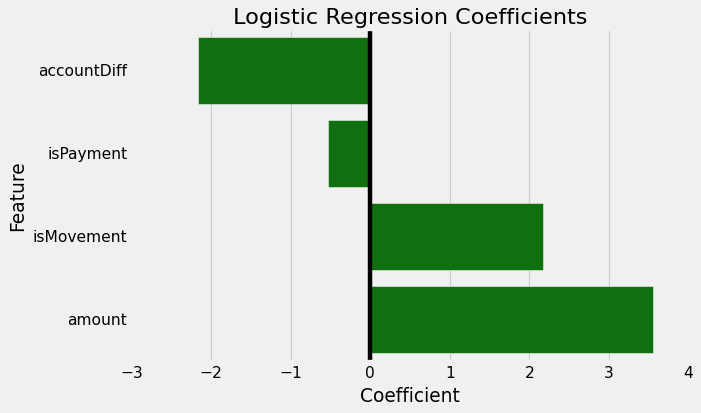

In [ ]:
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr.coef_[0]258369
}).sort_values(by='Coefficient')

plt.figure(figsize=(8,5))
plt.style.use('fivethirtyeight')
sns.barplot(data=coef_df, x='Coefficient', y='Feature', color='green')
plt.title('Logistic Regression Coefficients')
plt.axvline(0, color='black')
plt.show()


# Logistic Model Summary

We have evaluted two logistic regressio models:
1. The first model includes mismatch balance features  (`origBalanceMismatch`, `destBalanceMismatch`)
2. The second model uses only transactional and behavioral features (`amount`, `accountDiff`, `isPayment`, `isMovement`)


#### While the model with balance mismatch features achieved near-perfect performance on this synthetic dataset, it may be overly optimistic due to the deterministic nature of those features in simulated data.

#### After removing the mismatch features, the model still achieved strong performance (ROC-AUC ≈ 0.90) with improved robustness and interpretability. This suggests that behavioral and monetary signals alone provide meaningful fraud detection capability.

#### For the final step, I will use the simpler feature set to better reflect real-world situation of limited known features.


# Using the Model on New Transactions
### We will evaluate 4 transactions using the above preprocessing pipeline as the training data. The model will output both a predicted class and an associated probability, allowing for nuanced decision-making rather than relying on a binary label.

In [ ]:
# New transaction data
transaction1 = np.array([123456.78, 0.0, 1.0, 54670.1])
transaction2 = np.array([98765.43, 1.0, 0.0, 8524.75])
transaction3 = np.array([543678.31, 1.0, 0.0, 510025.5])
transaction4 = np.array([734104.8, 0.0, 1.0, 14975.6])

# Combine new transactions into a single array
my_transactions = np.stack((transaction1, transaction2, transaction3, transaction4))

# Turn this NumPy array into a DataFrame, to avoid the 'feature names are missing' warning from sklearn
my_transactions_df = pd.DataFrame(my_transactions,
                               columns= ['amount', 'isPayment', 'isMovement',
                                         'accountDiff'])

# Normalize the new transactions
my_transactions_ss_df = ss.transform(my_transactions_df)

# Predict fraud on the new transactions
preds= lr.predict(my_transactions_ss_df)

# Show probabilities on the new transactions
probs = lr.predict_proba(my_transactions_ss_df)

for i in range(len(preds)):
  print(f'Transaction {i+1}:')
  print(f"Predicted class: {'Fraud' if preds[i] == 1 else 'Not Fraud'}")
  print(f'Probability of NOT fraud: {probs[i][0]: 0.2%}')
  print(f'Probability of fraud: {probs[i][1]: 0.2%}')
  print('-' * 40)

Transaction 1:
Predicted class: Not Fraud
Probability of NOT fraud:  65.29%
Probability of fraud:  34.71%
----------------------------------------
Transaction 2:
Predicted class: Not Fraud
Probability of NOT fraud:  99.82%
Probability of fraud:  0.18%
----------------------------------------
Transaction 3:
Predicted class: Not Fraud
Probability of NOT fraud:  99.74%
Probability of fraud:  0.26%
----------------------------------------
Transaction 4:
Predicted class: Fraud
Probability of NOT fraud:  28.42%
Probability of fraud:  71.58%
----------------------------------------


# The Results

The outputs show that the model predicts low fraud probabilities for Transactions 2 and 3 while flagging Transaction 4 as high-risk with a fraud probability above 70%. Transaction 1 falls closer to the decision boundary, indicating how probability scores can help review borderline cases instead of making rigid positive/negative determinations.